In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("./data/processed_loan_dataset.csv")
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
1,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
2,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
3,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
4,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected


In [3]:
#one hot encode categorical columns
df["education"]=df["education"].map({" Not Graduate":0," Graduate":1})
df["self_employed"]=df["self_employed"].map({' Yes':1,' No':0})
df["loan_status"]=df["loan_status"].map({" Rejected":0," Approved":1})
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
1,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
2,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
3,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0
4,0,1,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0


In [3]:
X=df.drop("loan_status",axis=1)
y=df["loan_status"]

In [4]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [5]:
#Testing Models
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,roc_auc_score

def evaluate_models(X_train, y_train, X_test, y_test, models, params, cv=5, scoring='accuracy'):
    results = {}
    best_model = None
    best_score = 0
    best_model_name = None
    best_model_params = None

    for model_name, model in models.items():
        print(f"Training and tuning {model_name}...")
        param_grid = params[model_name]
        grid = GridSearchCV(model, param_grid, cv=cv, scoring=scoring)
        grid.fit(X_train, y_train)
        
        best_estimator = grid.best_estimator_
        y_pred = best_estimator.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        prec=precision_score(y_test,y_pred)
        rec=recall_score(y_test,y_pred)
        f1=f1_score(y_test,y_pred)
        roc=roc_auc_score(y_test,y_pred)
        
        results[model_name] = {
            'accuracy': acc,
            'precision':prec,
            'recall':rec,
            'f1 score':f1,
            'roc_auc_score':roc,
            'best_params': grid.best_params_,
            'model': best_estimator
        }

        if acc > best_score:
            best_score = acc
            best_model = best_estimator
            best_model_name = model_name
            best_model_params = grid.best_params_
    
    print(f"\nBest model: {best_model_name} with accuracy: {best_score:.4f}")
    
    return {
        'all_results': results,
        'best_model_name': best_model_name,
        'best_model': best_model,
        'best_accuracy': best_score,
        'best_params': best_model_params
    }


In [6]:
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import warnings
from sklearn.neighbors import KNeighborsClassifier
warnings.filterwarnings("ignore", category=FutureWarning)

In [7]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1500),
    'NaiveBayes': GaussianNB(),
    'RandomForest': RandomForestClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
    'KNN': KNeighborsClassifier()
}

# Define hyperparameters
params = {
    'LogisticRegression': {
        'C': [0.001,0.01,0.1, 1, 5, 10],
        'solver': ['lbfgs', 'liblinear']
    },
    'NaiveBayes': {},  # No tuning needed for GaussianNB (can be left empty)
    'RandomForest': {
        'n_estimators': [40,50,60,80,100],
        'max_depth': [None,3,5,7]
    },
    'XGBoost': {
        'n_estimators': [30,40,50,60,80,100],
        'max_depth': [3,5,7],
        'learning_rate': [0.01,0.05,0.1]
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11, 13],
        'weights': ['uniform', 'distance'],
        'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
    }
}

# Call the evaluation function
results = evaluate_models(X_train, y_train, X_test, y_test, models, params)

# Print best model details
print("\nBest Model Summary:")
print(f"Model Name: {results['best_model_name']}")
print(f"Best Accuracy: {results['best_accuracy']:.4f}")
print(f"Best Params: {results['best_params']}")

Training and tuning LogisticRegression...
Training and tuning NaiveBayes...
Training and tuning RandomForest...
Training and tuning XGBoost...


/home/sanjeetraj/Projects/DiamondPricePrediction/myvenv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [00:15:38] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/sanjeetraj/Projects/DiamondPricePrediction/myvenv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [00:15:38] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/sanjeetraj/Projects/DiamondPricePrediction/myvenv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [00:15:38] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/sanjeetraj/Projects/DiamondPricePrediction/myvenv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [00:15:38] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "

Training and tuning KNN...

Best model: XGBoost with accuracy: 0.9818

Best Model Summary:
Model Name: XGBoost
Best Accuracy: 0.9818
Best Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 80}


In [15]:
report=pd.DataFrame(results["all_results"]).T
report.sort_values("accuracy",ascending=False)

,accuracy,precision,recall,f1 score,roc_auc_score,best_params,model
XGBoost,0.981818,0.993837,0.977273,0.985485,0.983442,"{'learning_rate': 0.1, 'max_depth': 7, 'n_esti...","XGBClassifier(base_score=None, booster=None, c..."
RandomForest,0.973206,0.989164,0.968182,0.97856,0.975,"{'max_depth': None, 'n_estimators': 50}","(DecisionTreeClassifier(max_features='sqrt', r..."
LogisticRegression,0.818182,0.804404,0.940909,0.867318,0.774351,"{'C': 0.01, 'solver': 'lbfgs'}","LogisticRegression(C=0.01, max_iter=1500)"
NaiveBayes,0.771292,0.748524,0.960606,0.841407,0.70368,{},GaussianNB()
KNN,0.566507,0.628892,0.765152,0.690362,0.495563,"{'algorithm': 'auto', 'n_neighbors': 9, 'weigh...",KNeighborsClassifier(n_neighbors=9)


In [16]:
best_model=results["best_model"]
y_pred=best_model.predict(X_test)


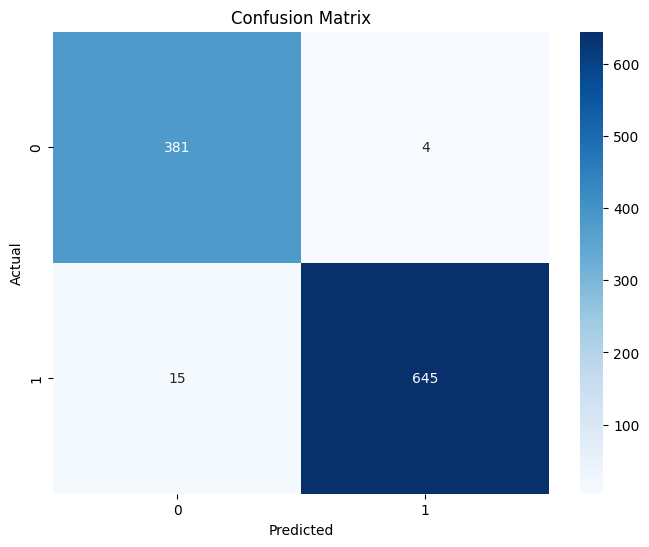

In [17]:
from sklearn.metrics import confusion_matrix
conf_matrix=confusion_matrix(y_test,y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()